## Test Our AutoDiff Engine in a ToyDataset 

In [10]:
import numpy as np 
from helper import draw_dot
from nn import MLP 
from engine import Value 
import matplotlib.pyplot as plt

### 1. Visualize Dataset 

In [2]:
from sklearn.datasets import make_circles 

X,y = make_circles(n_samples=1000,shuffle=True)
X.shape,y.shape

((1000, 2), (1000,))

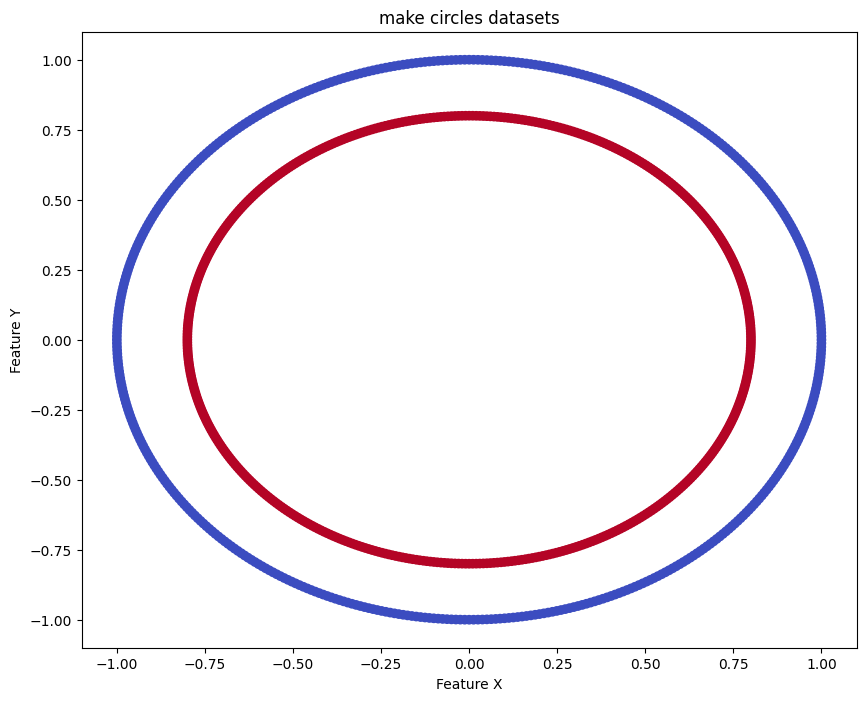

In [3]:
plt.figure(figsize=(10,8))
plt.scatter(X[:,0],X[:,1],c=y.ravel(),cmap="coolwarm")
plt.title("make circles datasets")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.show()

### 2. Train the Model to separate the two Circles  

In [4]:
model = MLP(nin=2,nouts=[16,16,1]) # 2-layer neural network
print(model)
print("number of parameters: ",len(model.parameters()))

MLP of : [Layer of [ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2), ReLU Neuron(2)], Layer of [ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16), ReLU Neuron(16)], Layer of [Linear Neuron(16)]]
number of parameters:  337


In [5]:
x1 = X[0]
print(model(x1))

Value | (data = -0.21109427511865325)


### 3. Loss function

In [6]:
def loss(batch_size=None):

    if batch_size:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb,yb = X[ri],y[ri]

    else:
        Xb,yb = X,y

    outputs = []
    for i in range(len(Xb)):
        score = model(Xb[i]).sigmoid() # [0,1] probabilities
        outputs.append(score)
    BCE = sum( -(yi* p.log() + (1-yi)* (1-p).log() ) for yi,p in zip(yb,outputs))
    BCE /= len(Xb)

    return BCE

In [7]:
num_epochs = 1000
lr = 0.05
for k in range(num_epochs):
    # 1. forward pass + loss
    loss_value = loss(batch_size=32)

    # 2. zero_grad
    model.zero_grad()

    # 3. backward pass
    loss_value.backward()

    # update parameters
    for p in model.parameters():
        p.data = p.data -lr*p.grad

    if k%10 == 0:
        print(k,loss_value.data)


0 1.1363336707307654
10 0.7752611906471513
20 0.7069213682468204
30 0.6939436259475548
40 0.7038040601109463
50 0.6254126010440944
60 0.6422736414929879
70 0.6974021150512103
80 0.6744136191533915
90 0.6502081400163336
100 0.6648134216428836
110 0.5834099881162995
120 0.5916165580129449
130 0.6696172690478381
140 0.6286768185268333
150 0.6386579761907463
160 0.5799491959879529
170 0.5472204443486474
180 0.6174194114021788
190 0.5716799810646334
200 0.557766979930128
210 0.5659976223162944
220 0.6339086928317776
230 0.5733310920925877
240 0.5911626539824032
250 0.5496227204757053
260 0.5567953738148274
270 0.5303099267006987
280 0.5384236227286177
290 0.5536736767312608
300 0.5298015466781393
310 0.5410518017946249
320 0.5154060955955682
330 0.5409899447267487
340 0.5451561530771906
350 0.5361506800320761
360 0.5045777789820061
370 0.5016946969121161
380 0.5013450464416671
390 0.48063989793694406
400 0.4905719090173872
410 0.4764088930900425
420 0.4626455438339684
430 0.4574201915685685

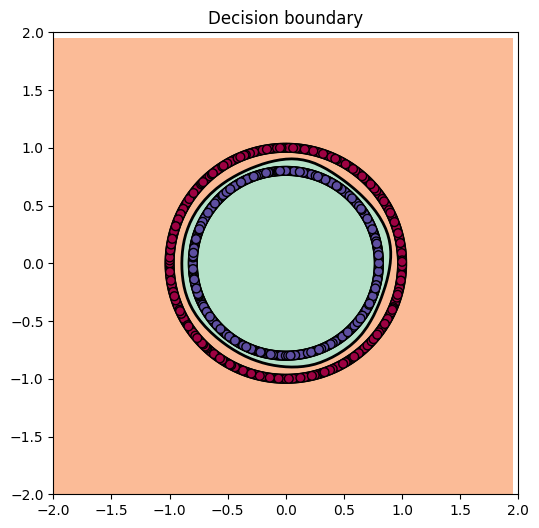

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, h=0.05):
    # 1. Build a grid covering the data range with some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))

    # 2. Run the model on every point in the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    scores = []
    for point in grid_points:
        logit = model([Value(point[0]), Value(point[1])])
        prob = logit.sigmoid().data   # convert to probability
        scores.append(prob)
    Z = np.array(scores).reshape(xx.shape)

    # 3. Plot the filled contour (decision regions) + original data points
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=plt.cm.Spectral, alpha=0.6)
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # the boundary line itself
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolors='k', s=40)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.title("Decision boundary")
    plt.show()

plot_decision_boundary(model,X,y)

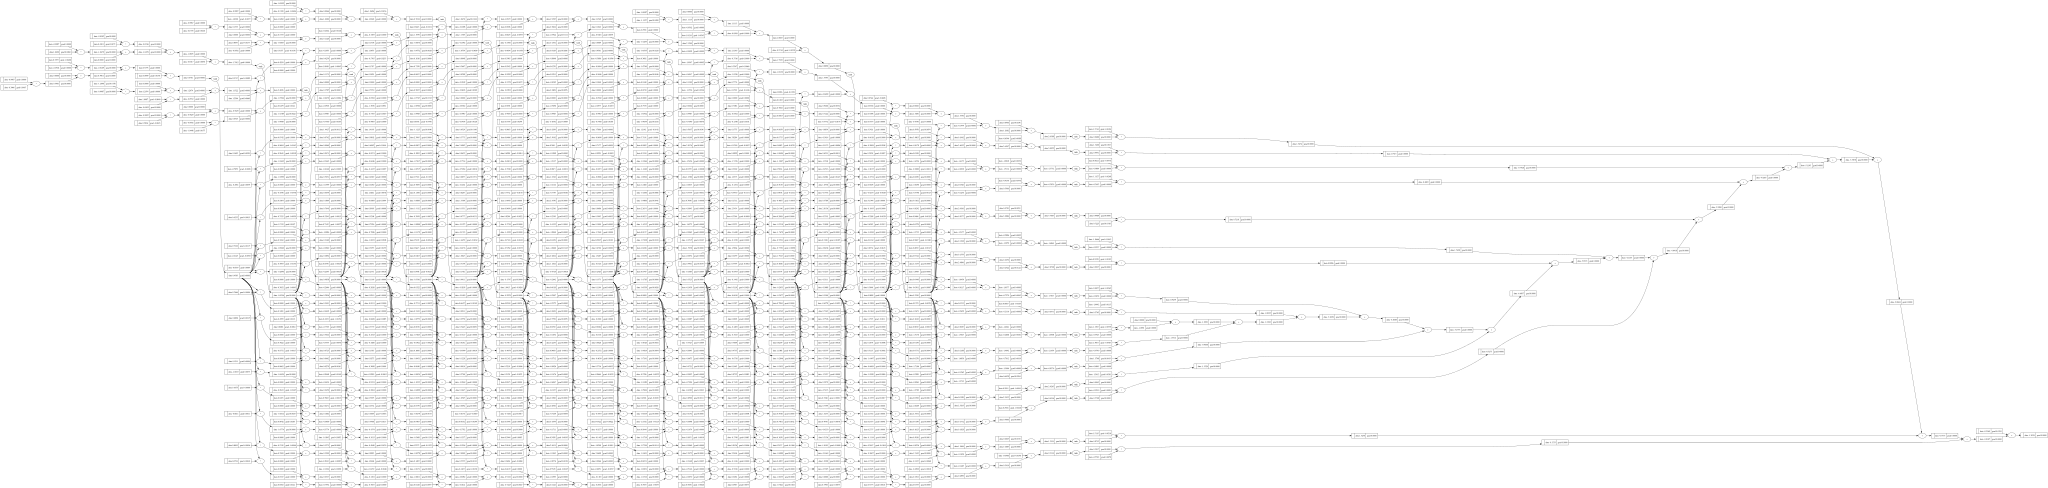

In [13]:
draw_dot(model(X[1]))